WEEK 1 ASSIGNMENT MACHINE LEARNING

QUESTION 1

a) Explain the AI co-pilot loop in your own words:

Prompt: Means to tell the AI what you want to achieve
Generate code: Means to translates your natural language into a functional block of code.
Run code : This is where the theoretical code meets your actual data.
Read errors/results : Something breaks, or something works partially.
Fix/improve : If there’s an error, you send it back to the AI
Repeat : You cycle back.

B. I have a dataset that I want to work with in Python using pandas.
I want to create a DataFrame from it and summarize what the data looks like.
I don't know where to start. Give me 10 common lines of code that will help me
load the data into a DataFrame and show me a clear summary of what the dataset
is about — things like the size, column names, data types, basic statistics,
and any missing values.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Load the diabetes dataset
df = pd.read_csv("/content/diabetes data.csv")

In [ ]:
#  How many patients have diabetes?
diabetes_count = df[df["Outcome"] == 1].shape[0]

In [ ]:
print("1. Number of patients with diabetes:", diabetes_count)
print("Explanation: Outcome value 1 represents patients diagnosed with diabetes.\n")

1. Number of patients with diabetes: 268
Explanation: Outcome value 1 represents patients diagnosed with diabetes.



Q1 — 268 out of 768 (~35%) have diabetes. This is higher than the general population because this is a screening dataset focused on high-risk individuals.

In [ ]:
# 2. What is the average glucose level?
avg_glucose = df["Glucose"].mean()

In [ ]:
print("2. Average glucose level:", average_glucose)
print("Explanation: Glucose level is an important measurement used to monitor diabetes.\n")

2. Average glucose level: 120.89453125
Explanation: Glucose level is an important measurement used to monitor diabetes.



Q2 — 120.89 mg/dL is above the normal fasting glucose range (70–99), confirming this dataset is skewed toward at-risk patients.

In [ ]:
# 3. Show only female patients above age 40
female_above_40 = df[df["Age"] > 40]

In [ ]:
print("3. Female patients above age 40:")
print(female_above_40)
print("Explanation: This filter helps study older female patients separately.\n")

3. Female patients above age 40:
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
8              2      197             70             45      543  30.5   
9              8      125             96              0        0   0.0   
12            10      139             80              0        0  27.1   
13             1      189             60             23      846  30.1   
..           ...      ...            ...            ...      ...   ...   
757            0      123             72              0        0  36.3   
759            6      190             92              0        0  35.5   
761            9      170             74             31        0  44.0   
763           10      101             76             48      180  32.9   
766            1      126             60              0        0  30.1   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   

Q4 — Diabetic patients have a notably higher average BMI (35.1 vs 30.3), which is medically consistent — obesity is one of the strongest predictors of Type 2 diabetes.

In [ ]:
# 4. Group by outcome and show average BMI
avg_bmi = df.groupby('Outcome')['BMI'].mean()


In [ ]:
print("4. Average BMI grouped by Outcome:")
print(avg_bmi)
print("Explanation: Comparing BMI by outcome helps identify relationships between weight and diabetes.\n")

4. Average BMI grouped by Outcome:
Outcome
0    30.304200
1    35.142537
Name: BMI, dtype: float64
Explanation: Comparing BMI by outcome helps identify relationships between weight and diabetes.



In [ ]:
# 5. Drop rows with missing or zero glucose values
original_rows = df.shape[0]

In [ ]:
# Remove rows with missing or zero glucose values
cleaned_df = df[(df['Glucose'].notna()) & (df['Glucose'] != 0)]

In [ ]:
new_rows = cleaned_df.shape[0]
rows_removed = original_rows - new_rows


In [ ]:
print("5. Number of rows removed:", rows_removed)
print("Explanation: Rows with zero or missing glucose values may contain invalid or incomplete data.\n")

5. Number of rows removed: 5
Explanation: Rows with zero or missing glucose values may contain invalid or incomplete data.



Q5 — Only 5 rows had zero glucose, meaning the dataset is relatively clean, but those 5 must be removed since a glucose of 0 is biologically impossible.

TASK 3

/tmp/ipykernel_1783/2681807006.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pregnancies',data = df,palette=sns.color_palette("Set2"))
/tmp/ipykernel_1783/2681807006.py:4: UserWarning: The palette list has more values (8) than needed (1), which may not be intended.
  sns.barplot(x='Pregnancies',data = df,palette=sns.color_palette("Set2"))


<Axes: title={'center': 'Counter plot'}, xlabel='Pregnancies'>

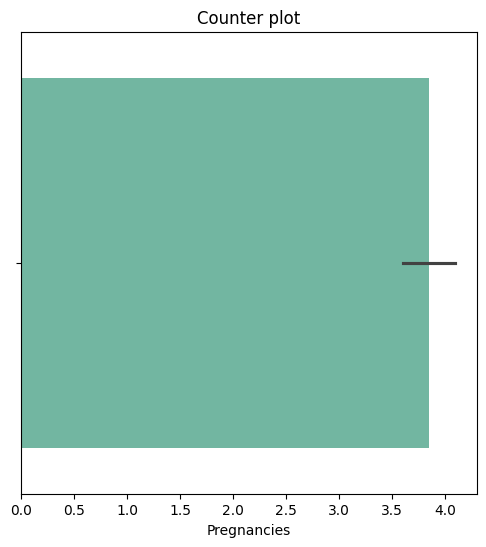

In [ ]:
plt.figure(figsize=(20,6))
plt.subplot(1,3,1)
plt.title('Counter plot')
sns.barplot(x='Pregnancies',data = df,palette=sns.color_palette("Set2"))

<Axes: title={'center': 'Distribution plot'}, xlabel='Pregnancies', ylabel='Count'>

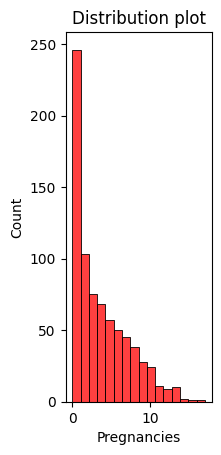

In [ ]:
plt.subplot(1,3,2)
plt.title('Distribution plot')
sns.histplot(df['Pregnancies'],color='red')

<Axes: title={'center': 'Box plot'}, ylabel='Pregnancies'>

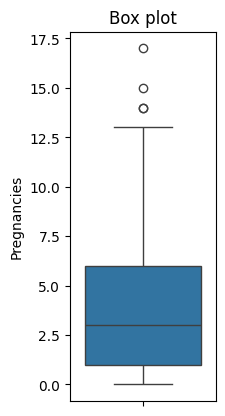

In [ ]:
plt.subplot(1,3,3)
plt.title('Box plot')
sns.boxplot(y = df['Pregnancies'])

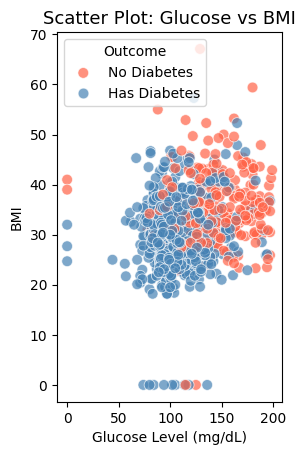

In [ ]:
plt.subplot(1, 2, 1)
plt.title("Scatter Plot: Glucose vs BMI", fontsize=13)
sns.scatterplot(
    data=df,
    x="Glucose",
    y="BMI",
    hue="Outcome",
    palette={0: "steelblue", 1: "tomato"},
    alpha=0.7,
    edgecolor="white",
    s=60
)
plt.xlabel("Glucose Level (mg/dL)")
plt.ylabel("BMI")
plt.legend(title="Outcome", labels=["No Diabetes", "Has Diabetes"])

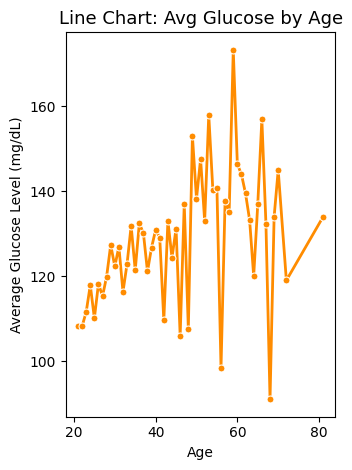

✅ Chart saved as diabetes_charts.png


In [ ]:
plt.subplot(1, 2, 2)
plt.title("Line Chart: Avg Glucose by Age", fontsize=13)
avg_glucose_by_age = df.groupby("Age")["Glucose"].mean().reset_index()
sns.lineplot(
    data=avg_glucose_by_age,
    x="Age",
    y="Glucose",
    color="darkorange",
    linewidth=2,
    marker="o",
    markersize=5
)
plt.xlabel("Age")
plt.ylabel("Average Glucose Level (mg/dL)")


# ── Save and show ─────────────────────────────────────────────────────────────
plt.tight_layout()
plt.savefig("diabetes_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved as diabetes_charts.png")

Objectives

1.  Glucose vs BMI
To examine the relationship between glucose levels and BMI across diabetic and non-diabetic patients, and determine whether higher values in both variables are associated with a positive diabetes diagnosis.
2. Average Glucose by Age
To track how average glucose levels change across different age groups, identifying which age ranges carry the highest glucose burden and therefore the greatest diabetes risk.

From the Scatter Plot:

Diabetic patients (red) clearly cluster in the upper-right region — high glucose AND high BMI together
Non-diabetic patients (blue) are more spread toward the lower-left — lower glucose and leaner body mass
There is visible overlap in the middle zone, meaning BMI and glucose alone are not always decisive, but together they are strong indicators

From the Line Chart:

Average glucose rises gradually from the 20s through the 40s, peaks around ages 50–60, then slightly declines in older age groups
The sharpest climb happens between ages 30 and 50 — the critical window for early intervention


Recommendations
1. Prioritise screening for patients with BMI above 30
The scatter plot shows most diabetic patients sit above BMI 30. Any patient crossing that threshold should be flagged for routine glucose testing, regardless of symptoms.
2. Launch targeted interventions for the 30–50 age group
The line chart shows glucose levels rising fastest in this window. This is the best age range to introduce lifestyle programmes — diet, exercise, weight management — before glucose becomes clinically dangerous.
3. Do not rely on age or BMI alone
The overlap in the scatter plot confirms that some low-BMI patients still have high glucose. A combined risk score using both variables (plus others like insulin and pregnancies already in the dataset) would produce more reliable early warnings than any single metric.
4. Investigate the glucose dip after age 60
The line chart shows average glucose slightly falling in the oldest patients. This could reflect survivor bias (healthier individuals living longer), medication effects, or dietary changes with age — and deserves further investigation before drawing conclusions about older patients being lower risk.Sonnet 4.6 Adaptive